# Coursework 2

In this coursework, you will implement three different recommendation systems to recommend movies to users. Please read carefully the instructions provided in e-class.

In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Import the data in 'U.csv'

In [150]:
df = pd.read_csv('U.csv', header=None)
R = df.values.astype(float)
R

array([[5., 3., 4., ..., 0., 0., 0.],
       [4., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [5., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 5., 0., ..., 0., 0., 0.]], shape=(943, 1682))

### Exercise 1 
Original_row = [0, 3, 0, 5, 2, 0, 0, 0]

Let's say val = position 1 (3), test = position 4 (2), train = position 3 (5)

- Train_row = [0, 0, 0, 5, 0, 0, 0, 0]
- Val_row = [0, 3, 0, 0, 0, 0, 0, 0]
- Test_row = [0, 0, 0, 0, 2, 0, 0, 0]

In [151]:
def train_test_split(R, seed=42):
    n_users, n_items = R.shape
    rng = np.random.default_rng(seed)

    matrix_train = []
    matrix_valid = []
    matrix_test = []

    split_info = []

    for i in range(n_users):
        row = R[i]
        rated_indices = np.where(row != 0)[0]

        if len(rated_indices) < 10:
            matrix_train.append(row.copy())
            matrix_valid.append(np.zeros(n_items))
            matrix_test.append(np.zeros(n_items))
            split_info.append(([], []))
            continue

        shuffled = rated_indices.copy()
        rng.shuffle(shuffled)

        test_idx = shuffled[:5]
        valid_idx = shuffled[5:10]
        train_idx = shuffled[10:]

        train_row = row.copy()
        train_row[test_idx] = 0
        train_row[valid_idx] = 0

        valid_row = np.zeros(n_items)
        valid_row[valid_idx] = row[valid_idx]

        test_row = np.zeros(n_items)
        test_row[test_idx] = row[test_idx]

        matrix_train.append(train_row)
        matrix_valid.append(valid_row)
        matrix_test.append(test_row)

        split_info.append((valid_idx, test_idx))

    R_train = np.array(matrix_train)
    R_valid = np.array(matrix_valid)
    R_test = np.array(matrix_test)

    cols_with_ratings = np.any(R_train != 0, axis=0)
    if not np.all(cols_with_ratings):
        empty_cols = np.where(~cols_with_ratings)[0]
        print(f"Fixing empty columns in R_train: {empty_cols}")

        for col in empty_cols:
            users_with_rating = np.where(R[:, col] != 0)[0]
            rng.shuffle(users_with_rating)
            for u in users_with_rating:
                if R_valid[u, col] != 0:
                    R_train[u, col] = R_valid[u, col]
                    R_valid[u, col] = 0
                    break
                elif R_test[u, col] != 0:
                    R_test[u, col] = 0
                    break

    return R_train, R_valid, R_test

R_train, R_valid, R_test = train_test_split(R)

print("Train matrix shape:", R_train.shape)
print("Validation matrix shape:", R_valid.shape)
print("Test matrix shape:", R_test.shape)

print("Original first row:", R[0])
print("============================================")
print("Train first row:   ", R_train[0])
print("Valid first row:   ", R_valid[0])
print("Test first row:    ", R_test[0])
print("============================================")


Fixing empty columns in R_train: [1308 1524 1595 1620 1652 1653 1678]
Train matrix shape: (943, 1682)
Validation matrix shape: (943, 1682)
Test matrix shape: (943, 1682)
Original first row: [5. 3. 4. ... 0. 0. 0.]
Train first row:    [5. 3. 4. ... 0. 0. 0.]
Valid first row:    [0. 0. 0. ... 0. 0. 0.]
Test first row:     [0. 0. 0. ... 0. 0. 0.]


In [152]:
def check_empty_columns(R_train):
    cols_with_ratings = np.any(R_train != 0, axis=0)
    if not np.all(cols_with_ratings):
        empty_cols = np.where(~cols_with_ratings)[0]
        print(f"empty columns: {empty_cols}")
        print(f"total: {len(empty_cols)} empty columns.")
        return False
    else:
        print("doesnt exist empty columns in R train.")
        return True
check_empty_columns(R_train)

empty columns: [1308 1524 1595 1620 1678]
total: 5 empty columns.


False

In [153]:
print("Train:", np.unique(R_train[R_train > 0]))
print("Valid:", np.unique(R_valid[R_valid > 0]))
print("Test:",  np.unique(R_test[R_test > 0]))


Train: [1. 2. 3. 4. 5.]
Valid: [1. 2. 3. 4. 5.]
Test: [1. 2. 3. 4. 5.]


In [154]:
print("Train min/max:", R_train[R_train > 0].min(), R_train[R_train > 0].max())

Train min/max: 1.0 5.0


### Exercise 2. NMF - Non-negative Matrix Factorization without regularization

**Problem Formulation**

The objective of NMF is to find two non-negative matrices $\mathbf{W} \in \mathbb{R}^{m \times k}$ and $\mathbf{H} \in \mathbb{R}^{k \times n}$ that approximate the ratings matrix $\mathbf{R} \in \mathbb{R}^{m \times n}$:

$\mathbf{R} \approx \mathbf{W} \mathbf{H}$

**Objective Function**

The objective function that we minimize is the squared Frobenius norm:

$J = \frac{1}{2} \|\mathbf{R} - \mathbf{W} \mathbf{H}\|_F^2 = \frac{1}{2} \sum _{i=1}^{m} \sum_{j=1}^{n} \left(r_{ij} - (\mathbf{W} \mathbf{H})_{ij} \right)^2$

subject to restrictions:

- $\mathbf{W} \geq 0$

- $\mathbf{H} \geq 0$

**Multiplicative Update Rules**

- For the matrix H:

$H_{ij} \leftarrow H_{ij} \frac{(\mathbf{W}^T \mathbf{R})_{ij}}{(\mathbf{W}^T \mathbf{W} \mathbf{H})_{ij} + \epsilon}$

- For the matrix W:**

$W_{ij} \leftarrow W_{ij} \frac{(\mathbf{R} \mathbf{H}^T)_{ij}}{(\mathbf{W} \mathbf{H} \mathbf{H}^T)_{ij} + \epsilon}$

**Explanation of the Frobenius Norm**

The Frobenius norm of a matrix $\mathbf{A}$ is defined as:

$\|\mathbf{A}\|_F = \sqrt{ \sum _{i=1}^{m} \sum _{j=1}^{n} a_{ij}^2 }$

And the Frobenius norm squared is:

$\|\mathbf{A}\|_F^2 = \sum _{i=1}^{m} \sum _{j=1}^{n} a_{ij}^2$

In the context of NMF:

The objective function that we minimize is:

$J = \frac{1}{2} \| \mathbf{R} - \mathbf{W} \mathbf{H} \|_F^2$

Expanding this:

$J = \frac{1}{2} \sum _{i=1}^{m} \sum _{j=1}^{n} \left(r_{ij} - (\mathbf{W} \mathbf{H})_{ij} \right)^2$


In [156]:
def nmf(R, k=10, max_iter=1000, tol=0.01):
    m, n = R.shape
    np.random.seed(42)  

    # Initialize W with small non-negative values
    W = np.random.uniform(0.01, 0.1, (m, k))
    H = np.random.uniform(0.01, 0.1, (k, n))
    losses = []
    epsilon = 1e-9 
    
    for iteration in range(max_iter):
        W_old = W.copy() # It is before the update step
        H_old = H.copy() # It is before the update step
        
        R_approx = W @ H
        loss = 0.5 * np.sum((R - R_approx) ** 2)
        losses.append(loss)
        
        numerator_H = W.T @ R
        denominator_H = W.T @ W @ H + epsilon
        H = H * (numerator_H / denominator_H) # H_ij = H_ij * (W^T R)_ij / (W^T W H)_ij
        
        numerator_W = R @ H.T
        denominator_W = W @ H @ H.T + epsilon
        W = W * (numerator_W / denominator_W)  # W_ij = W_ij * (R H^T)_ij / (W H H^T)_ij
        
        relative_change_W = np.max(np.abs(W_old - W)) / np.max(W_old)
        relative_change_H = np.max(np.abs(H_old - H)) / np.max(H_old)
        
        max_relative_change = max(relative_change_W, relative_change_H)
        
        if max_relative_change < tol:
            print(f"Converged at iteration {iteration + 1}")
            break
    
    return W, H, losses


In [157]:
def nmf_predict(W, H):
    return W @ H

### Exercise 3. SLIM: Sparse Linear Method with Projected Gradient Descent

Learning $W$ for SLIM

$\min_W \frac{1}{2}\|R - RW\|_F^2 + \frac{\lambda_2}{2}\|W\|_F^2 + \lambda_1\|W\|_1$

where:

- $|\cdot|_F$ is the Frobenius norm

- $|\cdot|_1$ is the L1 norm

- $\lambda_1$ controls sparsity (L1 regularization)

- $\lambda_2$ controls smoothness (L2 regularization)

#### Derivación del Gradiente

Step 1: Expansion of the Objective Function

$L = \frac{1}{2} \mathrm{tr}[(R - RW)^T (R - RW)] + \frac{\lambda_2}{2} \mathrm{tr}[W^T W] + \lambda_1 \sum_{ij} |w_{ij}|$

Step 2: Derivative with respect to W

For the quadratic part:

$\frac{\partial}{\partial W} \frac{1}{2} \|R - RW\|_F^2 = -R^T (R - RW) = -R^T R + R^T RW$

For L2 regularization:

$\frac{\partial}{\partial W} \frac{\lambda_2}{2} \|W\|_F^2 = \lambda_2 W$

For regularization L1:

$\frac{\partial}{\partial W} \lambda_1 \|W\|_1 = \lambda_1 \cdot \mathrm{sign}(W)$

Full Gradient

$\nabla_W L = -R^T R + R^T RW + \lambda_2 W + \lambda_1 \cdot \mathrm{sign}(W)$

Gradient Descent Update

$W^{(t+1)} = W^{(t)} - ​​\alpha \nabla_W L$

where $\alpha$ is the learning rate.

In [ ]:
def slim(R, lr=0.005, lambda1=0.1, lambda2=0.1, max_iter=1000, tol=0.01):
    _, n = R.shape
    # Initialize W with small non-negative values
    np.random.seed(42)
    W = np.random.uniform(0.001, 0.01, (n, n))
    np.fill_diagonal(W, 0) 
    
    losses = []
    RTR = R.T @ R
    for iteration in range(max_iter):
        W_old = W.copy() # It is before the update step
        R_pred = R @ W
        
        # L = 0.5 * ||R - R*W||_F^2 + 0.5 * lambda2 * ||W||_F^2 + lambda1 * ||W||_1
        reconstruction_error = np.sum((R - R_pred) ** 2)
        l2_reg = lambda2 * np.sum(W ** 2)
        l1_reg = lambda1 * np.sum(np.abs(W))
        current_loss = 0.5 * reconstruction_error + 0.5 * l2_reg + l1_reg
        losses.append(current_loss)
        
        #gradient = -RTR + RTR @ W + lambda2 * W + lambda1 * np.sign(W) 
        gradient = -RTR + RTR @ W + lambda2 * W 

        W = W - lr * gradient
        W = np.sign(W) * np.maximum(np.abs(W) - lr * lambda1, 0)  # Soft thresholding
        W = np.maximum(W, 0) #W[i,j] >= 0
        np.fill_diagonal(W, 0) # W[i,i] = 0
        
        if iteration > 0: 
            max_change = np.max(np.abs(W_old - W))
            max_old = np.max(W_old)
            
            if max_old > 0:
                relative_change = max_change / max_old
                
                if relative_change < tol:
                    print(f"Convergence reached in iteration {iteration + 1}")
                    break

    return W, losses

In [159]:
def slim_predict(R, W):
    return R @ W

### Exercise 4. SVD with stochastic gradient descent (SGD).
$R_{m \times n} \approx U_{m \times k} V_{n \times k}^T$

Where:

- $R \in \mathbb{R}^{m \times n}$ is the original ratings matrix
- $U \in \mathbb{R}^{m \times k}$ contains the latent factors of users
- $V \in \mathbb{R}^{n \times k}$ contains the latent factors of items
- $k \ll \min(m,n)$ is the number of latent factors

**Loss Function**

$J = \sum _{(i,j) \in \Omega} \left[ (r_{ij} - \mathbf{u}_i^T \mathbf{v}_j)^2 + \lambda \left( \|\mathbf{u}_i\|^2 + \|\mathbf{v}_j\|^2 \right) \right]$

where:

- $r_{ij}$ is the real rating of user $i$ for item $j$
- $\lambda$ is the L2 regularization parameter
- $|\mathbf{u}i|^2 = \sum{f=1}^{k} u_{if}^2$ is the L2 norm squared

Prediction Error
$e_{ij} = r_{ij} - \hat{r}_{ij} = r_{ij} - \mathbf{u}_i^T \mathbf{v}_j$

Update $\mathbf{u}_i$, $\mathbf{v}_i$
- $\mathbf{u}_i \leftarrow \mathbf{u}_i + \alpha(e_{ij} \mathbf{v}_j - \lambda \mathbf{u}_i)$
- $\mathbf{v}_j \leftarrow \mathbf{v}_j + \alpha(e_{ij} \mathbf{u}_i - \lambda \mathbf{v}_j)$

In [ ]:
def svd_sgd(R, k=20, lr=0.01, lambda_reg=0.1, max_iter=1000, tol=0.01):
    m, n = R.shape
    np.random.seed(42)  

    # U: latent representation of users (m × k)
    # V: latent representation of items (n × k)
    U = np.random.uniform(0.001, 0.01, (m, k))
    V = np.random.uniform(0.001, 0.01, (n, k))
    losses = []

    rows, cols = np.where(R > 0)
    samples = list(zip(rows, cols))

    for it in range(max_iter):
        np.random.shuffle(samples)
        for i, j in samples:
            # e_ij = R_ij - Ŷ_ij
            eij = R[i, j] - np.dot(U[i], V[j])
            # U[i] ← U[i] + lr * (eij * V[j] - λ * U[i])
            U[i] += lr * (eij * V[j] - lambda_reg * U[i])
            # V[j] ← V[j] + lr * (eij * U[i] - λ * V[j])
            V[j] += lr * (eij * U[i] - lambda_reg * V[j])

        pred = U @ V.T
        mask = R > 0
        loss = np.mean((R[mask] - pred[mask]) ** 2)
        losses.append(loss)

        if it > 0 and abs(losses[-2] - loss) / (losses[-2] + 1e-10) < tol:
            print(f"Convergence in iteration {it}")
            break

    return U, V, losses


In [161]:
def svd_predict(U, V):
    return U @ V.T

### 5. Evaluate the performance of NMF, SLIM and SVD

In [162]:
def evaluate_model(R_true, R_pred, R_train=None, top_k=10):
    if R_train is not None:
        eval_mask = (R_true > 0) & (R_train == 0)
    else:
        eval_mask = R_true > 0

    mse = np.mean((R_true[eval_mask] - R_pred[eval_mask]) ** 2)
    rmse = np.sqrt(mse)

    recalls = []
    for u in range(R_true.shape[0]):
        true_row = R_true[u]
        pred_row = R_pred[u]

        relevant_items = np.where((true_row >= 4) & ((R_train is None) | (R_train[u] == 0)))[0]
        if len(relevant_items) == 0:
            continue  

        seen_items = np.where(R_train[u] > 0)[0] if R_train is not None else []
        candidate_items = np.setdiff1d(np.arange(R_pred.shape[1]), seen_items, assume_unique=True)
        top_predicted = candidate_items[np.argsort(pred_row[candidate_items])[::-1][:top_k]]

        hits = sum(item in relevant_items for item in top_predicted)
        recall_u = hits / len(relevant_items)
        recalls.append(recall_u)

    mean_recall = np.mean(recalls) if recalls else 0.0
    return rmse, mean_recall

In [163]:
def merge_train_validation(R_train, R_valid):
    return R_train + R_valid 

In [164]:
def grid_search_nmf(R_train, R_valid, ks=[10, 20], max_iter=1000):
    results = []
    for k in ks:
        print(f"\nTraining NMF with k={k}")
        W, H, losses = nmf(R_train, k=k, max_iter=max_iter)
        R_pred = nmf_predict(W, H)
        rmse, recall = evaluate_model(R_valid, R_pred, R_train)
        results.append({'model': 'NMF', 'k': k, 'rmse': rmse, 'recall': recall, 'losses': losses, 'W': W, 'H': H})
    return results

In [165]:
def grid_search_slim(R_train, R_valid, lrs=[0.001, 0.005], lambdas1=[0.05], lambdas2=[0.05], max_iter=1000):
    results = []
    for lr in lrs:
        for lambda1 in lambdas1:
            for lambda2 in lambdas2:
                print(f"\nTraining SLIM with lr={lr}, lambda1={lambda1}, lambda2={lambda2}")
                W, losses = slim(R_train, lr=lr, lambda1=lambda1, lambda2=lambda2, max_iter=max_iter)
                R_pred = slim_predict(R_train, W)
                rmse, recall = evaluate_model(R_valid, R_pred, R_train)
                results.append({
                    'model': 'SLIM', 'lr': lr, 'lambda1': lambda1, 'lambda2': lambda2,
                    'rmse': rmse, 'recall': recall, 'losses': losses, 'W': W
                })
    return results


In [166]:
def grid_search_svd_sgd(R_train, R_valid, ks=[10, 20], lrs=[0.005], lambdas=[0.1], max_iter=1000):
    results = []
    for k in ks:
        for lr in lrs:
            for lamb in lambdas:
                print(f"\nTraining SVD-SGD with k={k}, lr={lr}, lambda={lamb}")
                U, V, losses = svd_sgd(R_train, k=k, lr=lr, lambda_reg=lamb, max_iter=max_iter)
                R_pred = svd_predict(U, V)
                rmse, recall = evaluate_model(R_valid, R_pred, R_train)
                results.append({
                    'model': 'SVD-SGD', 'k': k, 'lr': lr, 'lambda': lamb,
                    'rmse': rmse, 'recall': recall, 'losses': losses, 'U': U, 'V': V
                })
    return results

In [167]:
def evaluate_best_model_nmf(best_result, R_train, R_valid, R_test):
    R_full = merge_train_validation(R_train, R_valid)
    W, H, _ = nmf(R_full, k=best_result['k'])
    R_pred = nmf_predict(W, H)
    rmse, recall = evaluate_model(R_test, R_pred, R_full)
    print(f"Test RMSE: {rmse:.4f}, Test Recall@10: {recall:.4f}")
    return rmse, recall


In [168]:
def evaluate_best_model_slim(best_result, R_train, R_valid, R_test):
    R_full = merge_train_validation(R_train, R_valid)
    W, _ = slim(R_full, lr=best_result['lr'], lambda1=best_result['lambda1'], lambda2=best_result['lambda2'])
    R_pred = slim_predict(R_full, W)
    
    rmse, recall = evaluate_model(R_test, R_pred, R_full)
    print(f"Test RMSE: {rmse:.4f}, Test Recall@10: {recall:.4f}")
    return rmse, recall


In [169]:
def evaluate_best_model_svd(best_result, R_train, R_valid, R_test):
    R_full = merge_train_validation(R_train, R_valid)
    U, V, _ = svd_sgd(R_full, k=best_result['k'], lr=best_result['lr'], lambda_reg=best_result['lambda'])
    
    R_pred = svd_predict(U, V)
    rmse, recall = evaluate_model(R_test, R_pred, R_full)
    print(f"Test RMSE: {rmse:.4f}, Test Recall@10: {recall:.4f}")
    return rmse, recall



In [170]:
nmf_results = grid_search_nmf(
    R_train, R_valid,
    ks=[10, 20, 30],
    max_iter=1000
)

best_nmf = min(nmf_results, key=lambda r: r['rmse'])
print(f"\n[BEST NMF] k={best_nmf['k']} -> RMSE: {best_nmf['rmse']:.4f}, Recall@10: {best_nmf['recall']:.4f}")
nmf_test_rmse, nmf_test_recall = evaluate_best_model_nmf(best_nmf, R_train, R_valid, R_test)


Training NMF with k=10


Converged at iteration 46

Training NMF with k=20
Converged at iteration 67

Training NMF with k=30
Converged at iteration 60

[BEST NMF] k=30 -> RMSE: 2.8550, Recall@10: 0.2839
Converged at iteration 58
Test RMSE: 2.7726, Test Recall@10: 0.3140


In [171]:
slim_results = grid_search_slim(
    R_train, R_valid,
    lrs=[0.000001, 0.000005],
    lambdas1=[0.001, 0.01, 0.0001],
    lambdas2=[0.01, 0.05]
)

best_slim = min(slim_results, key=lambda r: r['rmse'])
print(f"\n[BEST SLIM] lr={best_slim['lr']}, lambda1={best_slim['lambda1']}, lambda2={best_slim['lambda2']} -> RMSE: {best_slim['rmse']:.4f}, Recall@10: {best_slim['recall']:.4f}")
slim_test_rmse, slim_test_recall = evaluate_best_model_slim(best_slim, R_train, R_valid, R_test)


Training SLIM with lr=1e-06, lambda1=0.001, lambda2=0.01
Convergence reached in iteration 70

Training SLIM with lr=1e-06, lambda1=0.001, lambda2=0.05
Convergence reached in iteration 70

Training SLIM with lr=1e-06, lambda1=0.01, lambda2=0.01
Convergence reached in iteration 70

Training SLIM with lr=1e-06, lambda1=0.01, lambda2=0.05
Convergence reached in iteration 70

Training SLIM with lr=1e-06, lambda1=0.0001, lambda2=0.01
Convergence reached in iteration 70

Training SLIM with lr=1e-06, lambda1=0.0001, lambda2=0.05
Convergence reached in iteration 70

Training SLIM with lr=5e-06, lambda1=0.001, lambda2=0.01
Convergence reached in iteration 56

Training SLIM with lr=5e-06, lambda1=0.001, lambda2=0.05
Convergence reached in iteration 56

Training SLIM with lr=5e-06, lambda1=0.01, lambda2=0.01
Convergence reached in iteration 56

Training SLIM with lr=5e-06, lambda1=0.01, lambda2=0.05
Convergence reached in iteration 56

Training SLIM with lr=5e-06, lambda1=0.0001, lambda2=0.01
Con

In [172]:
svd_sgd_results = grid_search_svd_sgd(
    R_train, R_valid,
    ks=[30, 40, 50],
    lrs=[0.005, 0.01],
    lambdas=[0.1, 0.15],
)

best_svd_sgd = min(svd_sgd_results, key=lambda r: r['rmse'])
print(f"\n[BEST SVD-SGD] k={best_svd_sgd['k']}, lr={best_svd_sgd['lr']}, lambda={best_svd_sgd['lambda']} -> RMSE: {best_svd_sgd['rmse']:.4f}, Recall@10: {best_svd_sgd['recall']:.4f}")
svd_test_rmse, svd_test_recall = evaluate_best_model_svd(best_svd_sgd, R_train, R_valid, R_test)


Training SVD-SGD with k=30, lr=0.005, lambda=0.1
Convergence in iteration 11

Training SVD-SGD with k=30, lr=0.005, lambda=0.15
Convergence in iteration 11

Training SVD-SGD with k=30, lr=0.01, lambda=0.1
Convergence in iteration 7

Training SVD-SGD with k=30, lr=0.01, lambda=0.15
Convergence in iteration 7

Training SVD-SGD with k=40, lr=0.005, lambda=0.1
Convergence in iteration 11

Training SVD-SGD with k=40, lr=0.005, lambda=0.15
Convergence in iteration 11

Training SVD-SGD with k=40, lr=0.01, lambda=0.1
Convergence in iteration 7

Training SVD-SGD with k=40, lr=0.01, lambda=0.15
Convergence in iteration 7

Training SVD-SGD with k=50, lr=0.005, lambda=0.1
Convergence in iteration 12

Training SVD-SGD with k=50, lr=0.005, lambda=0.15
Convergence in iteration 12

Training SVD-SGD with k=50, lr=0.01, lambda=0.1
Convergence in iteration 8

Training SVD-SGD with k=50, lr=0.01, lambda=0.15
Convergence in iteration 8

[BEST SVD-SGD] k=50, lr=0.01, lambda=0.1 -> RMSE: 0.9993, Recall@10: 

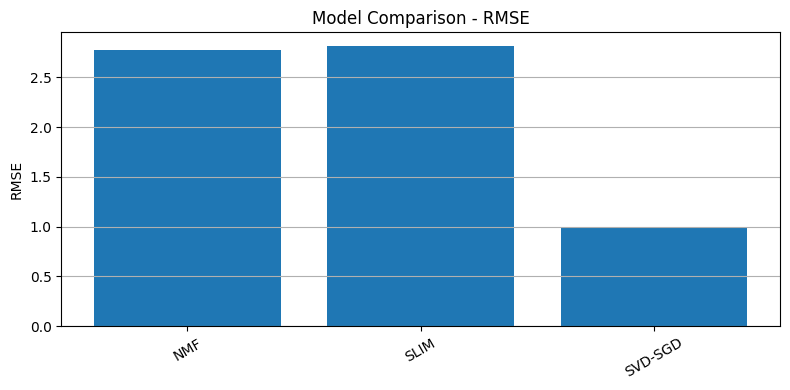

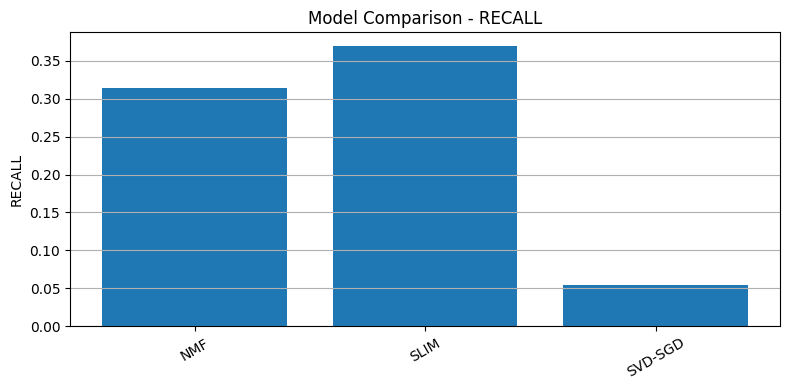

In [173]:
def plot_loss_curve(losses, title="Loss Curve"):
    plt.figure(figsize=(8, 4))
    plt.plot(losses, label='Training Loss')
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    
def plot_model_comparison(results, metric='rmse'):
    names = [f"{r['model']}" for r in results]
    values = [r[metric] for r in results]
    plt.figure(figsize=(8, 4))
    plt.bar(names, values)
    plt.ylabel(metric.upper())
    plt.title(f"Model Comparison - {metric.upper()}")
    plt.xticks(rotation=30)
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()


all_results = [
    {'model': 'NMF', 'rmse': nmf_test_rmse, 'recall': nmf_test_recall},
    {'model': 'SLIM', 'rmse': slim_test_rmse, 'recall': slim_test_recall},
    {'model': 'SVD-SGD', 'rmse': svd_test_rmse, 'recall': svd_test_recall}
]

plot_model_comparison(all_results, metric='rmse')
plot_model_comparison(all_results, metric='recall')


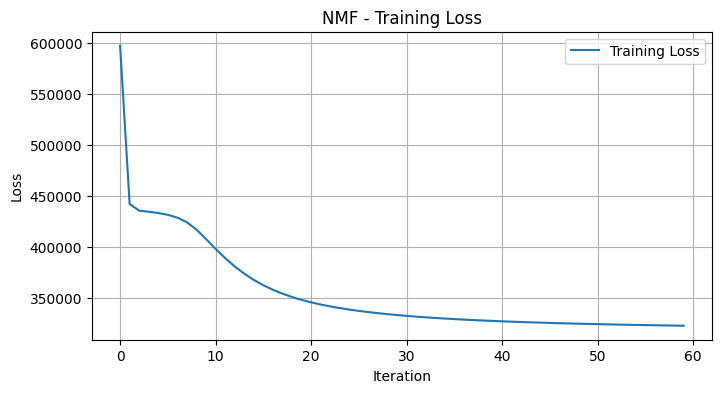

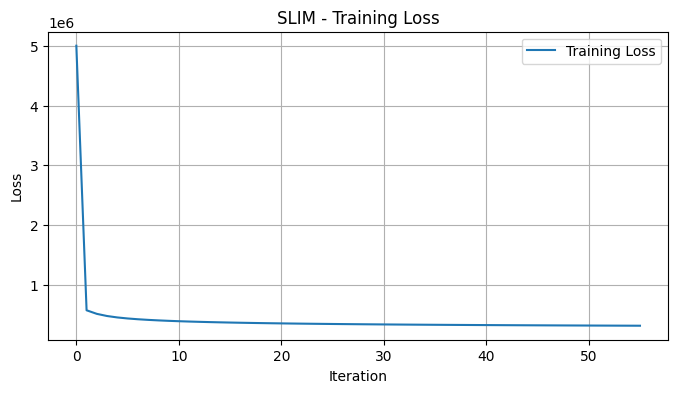

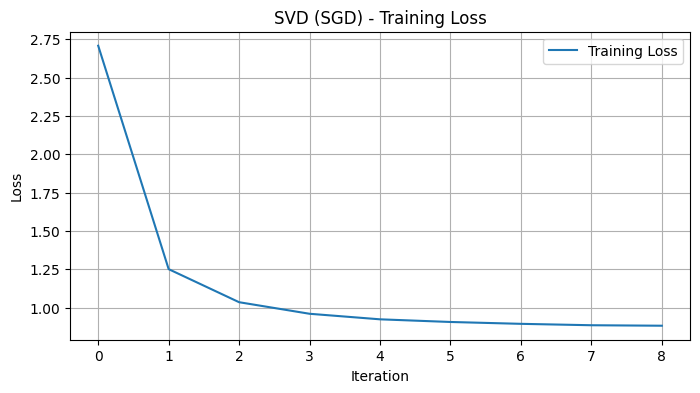

In [174]:
plot_loss_curve(best_nmf['losses'], title="NMF - Training Loss")
plot_loss_curve(best_slim['losses'], title="SLIM - Training Loss")
plot_loss_curve(best_svd_sgd['losses'], title="SVD (SGD) - Training Loss")
